In [3]:
import torch
import timm
import torchvision
import matplotlib.pyplot as plt
import tqdm

In [4]:
!pip install torch torchvision timm tqdm matplotlib

In [6]:
from data.datasets import get_cifar100_transforms
from fl.dataloaders import build_federated_dataloaders
from fl.fedavg import run_fedavg_experiment

ModuleNotFoundError: No module named 'fl.fedavg'

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

seed = 42
torch.manual_seed(seed)

device: cuda


In [7]:
transform_train, transform_test = get_cifar100_transforms()

client_loaders, val_loader, test_loader, *_ = build_federated_dataloaders(
    train_transform=transform_train,
    test_transform=transform_test,
    K=100,
    sharding="iid",
    val_ratio=0.1,
    batch_size=64,
    seed=seed
)

print("K clients:", len(client_loaders))
xb, yb = next(iter(client_loaders[0]))
print("client0 batch:", xb.shape, yb.shape)



K clients: 100
client0 batch: torch.Size([64, 3, 160, 160]) torch.Size([64])


In [8]:
from models.vit_dino import build_dino_vit
model = build_dino_vit()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [9]:
history, global_model = run_fedavg_experiment(
    base_model=model,
    client_loaders=client_loaders,
    test_loader=test_loader,
    rounds=100,
    C=0.1,
    J=4,
    lr=0.01,
    device=device,
    log_every=2
)

[FedAvg] rounds=100, K=100, C=0.1 => clients/round=10, J=4, lr=0.01
Round 001 | Test Acc:   0.94% | Avg client loss: 5.3523
Round 002 | Test Acc:   2.34% | Avg client loss: 5.2984
Round 004 | Test Acc:   3.83% | Avg client loss: 4.8070
Round 006 | Test Acc:   3.93% | Avg client loss: 4.6308
Round 008 | Test Acc:   4.72% | Avg client loss: 4.4820
Round 010 | Test Acc:   4.72% | Avg client loss: 4.4538
Round 012 | Test Acc:   6.31% | Avg client loss: 4.3985
Round 014 | Test Acc:   7.08% | Avg client loss: 4.3233
Round 016 | Test Acc:   6.03% | Avg client loss: 4.2722
Round 018 | Test Acc:   5.94% | Avg client loss: 4.2519
Round 020 | Test Acc:   8.59% | Avg client loss: 4.1732
Round 022 | Test Acc:   9.28% | Avg client loss: 4.0882
Round 024 | Test Acc:   9.30% | Avg client loss: 4.1402
Round 026 | Test Acc:  11.39% | Avg client loss: 4.0250
Round 028 | Test Acc:  11.12% | Avg client loss: 3.9458
Round 030 | Test Acc:  11.49% | Avg client loss: 3.8898
Round 032 | Test Acc:  12.18% | Avg 

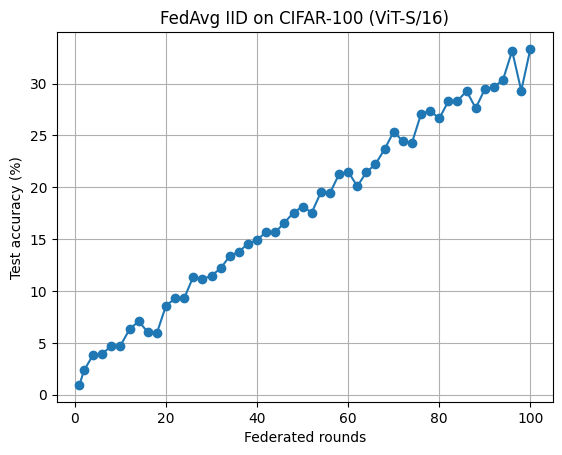

In [10]:
plt.plot(history["rounds"], history["test_acc"], marker="o")
plt.xlabel("Federated rounds")
plt.ylabel("Test accuracy (%)")
plt.title("FedAvg IID on CIFAR-100 (ViT-S/16)")
plt.grid(True)
plt.show()

In [11]:
%cd /content/Federated-Learning-Under-the-Lens-of-Task-Arithmetic
!git status

/content/Federated-Learning-Under-the-Lens-of-Task-Arithmetic
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data/cifar-100-python.tar.gz
	data/cifar-100-python/
	fl/fedavg.py

nothing added to commit but untracked files present (use "git add" to track)
